# A unified surface-forcing and n=3 shear history for ALHIC1901

This notebook asks whether one continuous idealized history can reproduce the three folds in the bottom 20 m of ALHIC1901. Alternating surface mass balance first deforms an initially ordered material coordinate in a numerical n=3 full-Stokes cell. The packet is then placed near the bed, optionally shortened horizontally, and sheared by a 160 m-thick n=3 full-Stokes slab. The model is fitted directly to the Shackleton et al. (2025) ages.

This is a mechanism and compatibility test, not a unique reconstruction. Its main advance over the two parent notebooks is that the fitted seed is no longer a freely chosen sinusoid: its geometry must come from an explicit accumulation–ablation history.

## Data and fixed fold targets

The fitting target and error treatment match the standalone ALHIC1901 notebook. The 88 $^{40}$Ar$_{ATM}$ ages are fitted individually with their relative errors and a 0.15 Ma model-discrepancy floor. Independently defined peaks in 0.6 m-bin medians between 141 and 155 m specify the three-fold target.

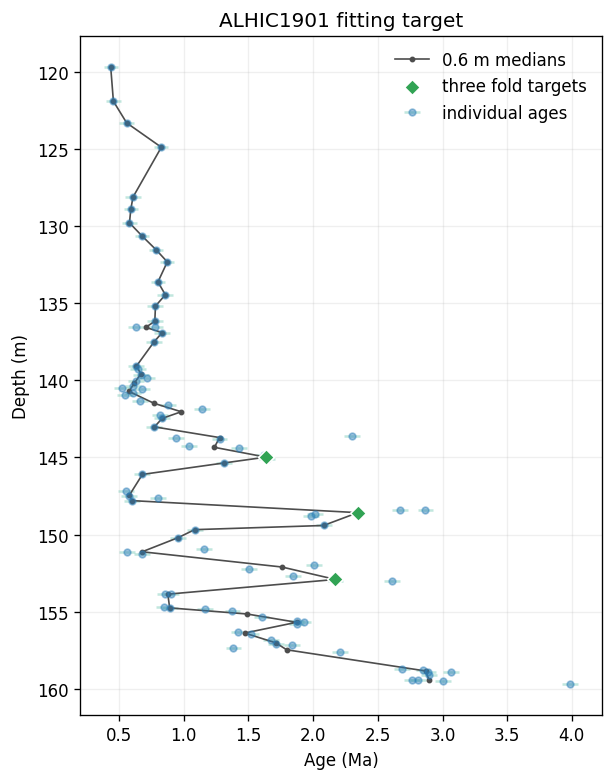

In [1]:
import logging
import warnings
from pathlib import Path

warnings.filterwarnings("ignore", message="Unable to import recommended hash.*")
warnings.filterwarnings("ignore", message="IProgress not found.*")

import numpy as np
import matplotlib.pyplot as plt
import openpyxl
from IPython.display import Markdown, display
from scipy.optimize import differential_evolution
from scipy.signal import find_peaks
import firedrake as fd

logging.getLogger("tsfc").setLevel(logging.ERROR)
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.2})

data_path = Path("data/shackleton.pnas.2502681122.sd01.xlsx")
if not data_path.exists():
    data_path = Path("../data/shackleton.pnas.2502681122.sd01.xlsx")
workbook = openpyxl.load_workbook(data_path, read_only=True, data_only=True)
sheet = workbook["Ar and Water isotopes"]
rows = [
    (float(row[1]), float(row[8]), float(row[9]), float(row[10]))
    for row in sheet.iter_rows(min_row=3, values_only=True)
    if row[0] == "ALHIC1901" and isinstance(row[8], (int, float))
]
observations = np.asarray(sorted(rows), dtype=float)
depth, age, relative_error, absolute_error = observations.T

BIN_WIDTH = 0.6
bin_edges = np.arange(119.5, 160.1 + BIN_WIDTH, BIN_WIDTH)
bin_depth, bin_age = [], []
for left, right in zip(bin_edges[:-1], bin_edges[1:]):
    selected = (depth >= left) & (depth < right)
    if np.any(selected):
        bin_depth.append(np.mean(depth[selected]))
        bin_age.append(np.median(age[selected]))
bin_depth, bin_age = np.asarray(bin_depth), np.asarray(bin_age)
fold_bins = (bin_depth >= 141.0) & (bin_depth <= 155.0)
peak_indices = find_peaks(bin_age[fold_bins], prominence=0.3, distance=3)[0]
observed_peak_depths = bin_depth[fold_bins][peak_indices]
observed_peak_ages = bin_age[fold_bins][peak_indices]
assert len(observed_peak_depths) == 3

fig, ax = plt.subplots(figsize=(5.0, 6.4), constrained_layout=True)
ax.errorbar(age, depth, xerr=relative_error, fmt="o", ms=4, alpha=0.48,
            color="#2c7fb8", ecolor="#7fcdbb", label="individual ages")
ax.plot(bin_age, bin_depth, ".-", color="0.3", lw=1, ms=5, label="0.6 m medians")
ax.scatter(observed_peak_ages, observed_peak_depths, marker="D", s=45,
           color="#31a354", edgecolor="white", zorder=5, label="three fold targets")
ax.invert_yaxis()
ax.set(xlabel="Age (Ma)", ylabel="Depth (m)", title="ALHIC1901 fitting target")
ax.legend(frameon=False)
plt.show()

## Two n=3 full-Stokes building blocks

Both stages solve $-\nabla\cdot(2\eta\dot{\boldsymbol\varepsilon}-p\mathbf I)=\rho\mathbf g$ and $\nabla\cdot\mathbf u=0$, with $\eta=\tfrac12A^{-1/n}(\dot\varepsilon_e^2+\dot\varepsilon_0^2)^{(1-n)/(2n)}$ and $n=3$.

The later flow is a 2 km by 160 m parallel slab on a 3% slope. Its bed is no slip, its surface is stress free, and its sides use the analytical Glen profile. The softness is calibrated to a surface speed of 0.0138 m yr$^{-1}$, matching the preceding ALHIC calculations, and the dimensional regularization is $10^{-10}$ yr$^{-1}$.

The surface stage is a periodic, six-wavelength-deep cell. Its top velocity is $(u',v')=(0,b\sin 2\pi x/\lambda)$, with $v'$ positive downward; its bottom perturbation is zero. Because pure Glen flow with velocity boundary conditions is homogeneous, a nondimensional softness of one and regularization $10^{-3}$ determine a reusable velocity shape. Physical amplitude and wavelength set the velocity and length scales. P2--P1 meshes are doubled in both directions for each stage.

In [2]:
L, H = 2_000.0, 160.0
RHO, G, ALPHA = 917.0, 9.81, 0.03
GLEN_N = 3.0
REFERENCE_MU = 2.5e8
EPS_REG = 1e-10
DRIVING = RHO * G * np.sin(ALPHA)
SURFACE_SPEED = DRIVING * H**2 / (2 * REFERENCE_MU)
SOFTNESS = SURFACE_SPEED * (GLEN_N + 1) / (2 * DRIVING**GLEN_N * H**(GLEN_N + 1))
UNIT_HEIGHT = 6.0
UNIT_EPS_REG = 1e-3

def analytical_velocity(z):
    return 2 * SOFTNESS * DRIVING**GLEN_N / (GLEN_N + 1) * (
        H**(GLEN_N + 1) - (H - z)**(GLEN_N + 1)
    )

def solve_slab(nx, nz):
    mesh = fd.RectangleMesh(nx, nz, L, H)
    V = fd.VectorFunctionSpace(mesh, "CG", 2)
    Q = fd.FunctionSpace(mesh, "CG", 1)
    mixed = V * Q
    z = fd.SpatialCoordinate(mesh)[1]
    solution = fd.Function(mixed, name=f"slab_n3_{nx}_{nz}")
    u, p = fd.split(solution)
    v, q = fd.TestFunctions(mixed)
    strain = fd.sym(fd.grad(u))
    effective_strain = fd.sqrt(0.5 * fd.inner(strain, strain) + EPS_REG**2)
    viscosity = 0.5 * SOFTNESS**(-1 / GLEN_N) * effective_strain**((1 - GLEN_N) / GLEN_N)
    body = fd.Constant((RHO * G * np.sin(ALPHA), -RHO * G * np.cos(ALPHA)))
    residual = (
        2 * viscosity * fd.inner(strain, fd.sym(fd.grad(v)))
        - p * fd.div(v) - q * fd.div(u) - fd.dot(body, v)
    ) * fd.dx
    side_velocity = fd.as_vector((analytical_velocity(z), 0.0))
    bcs = [
        fd.DirichletBC(mixed.sub(0), side_velocity, 1),
        fd.DirichletBC(mixed.sub(0), side_velocity, 2),
        fd.DirichletBC(mixed.sub(0), fd.Constant((0.0, 0.0)), 3),
    ]
    solution.sub(0).interpolate(side_velocity)
    solution.sub(1).interpolate(RHO * G * np.cos(ALPHA) * (H - z))
    fd.solve(residual == 0, solution, bcs=bcs, solver_parameters={
        "snes_type": "newtonls", "snes_linesearch_type": "bt", "snes_rtol": 1e-9,
        "ksp_type": "preonly", "pc_type": "lu", "pc_factor_mat_solver_type": "mumps",
    })
    velocity, pressure = solution.subfunctions
    heights = np.linspace(0.0, H, 1601)
    points = np.column_stack((np.full_like(heights, L / 2), heights))
    profile = np.asarray(velocity.at(points, tolerance=1e-10))[:, 0]
    divergence = fd.project(fd.div(velocity), Q)
    div_l2 = np.sqrt(float(fd.assemble(divergence**2 * fd.dx)))
    grad_l2 = np.sqrt(float(fd.assemble(fd.inner(fd.grad(velocity), fd.grad(velocity)) * fd.dx)))
    return {"velocity": velocity, "profile": profile, "heights": heights,
            "divergence_ratio": div_l2 / grad_l2, "nx": nx, "nz": nz}

def solve_surface_cell(nx, ny):
    mesh = fd.PeriodicRectangleMesh(nx, ny, 1.0, UNIT_HEIGHT, direction="x")
    V = fd.VectorFunctionSpace(mesh, "CG", 2)
    Q = fd.FunctionSpace(mesh, "CG", 1)
    mixed = V * Q
    x, z = fd.SpatialCoordinate(mesh)
    y = UNIT_HEIGHT - z
    solution = fd.Function(mixed, name=f"surface_n3_{nx}_{ny}")
    u, p = fd.split(solution)
    v, q = fd.TestFunctions(mixed)
    top_velocity = fd.as_vector((0.0, -fd.sin(2 * np.pi * x)))
    bcs = [
        fd.DirichletBC(mixed.sub(0), fd.Constant((0.0, 0.0)), 1),
        fd.DirichletBC(mixed.sub(0), top_velocity, 2),
    ]
    k = 2 * np.pi
    solution.sub(0).interpolate(fd.as_vector((
        -k * y * fd.exp(-k * y) * fd.cos(k * x),
        -(1 + k * y) * fd.exp(-k * y) * fd.sin(k * x),
    )))
    solution.sub(1).assign(0.0)
    nullspace = fd.MixedVectorSpaceBasis(
        mixed, [mixed.sub(0), fd.VectorSpaceBasis(constant=True)]
    )
    for exponent in (1.0, 1.5, 2.0, 2.5, 3.0):
        strain = fd.sym(fd.grad(u))
        effective_strain = fd.sqrt(0.5 * fd.inner(strain, strain) + UNIT_EPS_REG**2)
        viscosity = 0.5 * effective_strain**((1 - exponent) / exponent)
        residual = (
            2 * viscosity * fd.inner(strain, fd.sym(fd.grad(v)))
            - p * fd.div(v) - q * fd.div(u)
        ) * fd.dx
        fd.solve(
            residual == 0, solution, bcs=bcs, nullspace=nullspace,
            transpose_nullspace=nullspace,
            solver_parameters={
                "snes_type": "newtonls", "snes_linesearch_type": "bt", "snes_rtol": 1e-8,
                "ksp_type": "preonly", "pc_type": "lu",
                "pc_factor_mat_solver_type": "mumps",
                "mat_mumps_icntl_24": 1, "mat_mumps_icntl_13": 1,
            },
        )
    velocity, pressure = solution.subfunctions
    divergence = fd.project(fd.div(velocity), Q)
    div_l2 = np.sqrt(float(fd.assemble(divergence**2 * fd.dx)))
    grad_l2 = np.sqrt(float(fd.assemble(fd.inner(fd.grad(velocity), fd.grad(velocity)) * fd.dx)))
    return {"mesh": mesh, "velocity": velocity, "pressure": pressure,
            "divergence_ratio": div_l2 / grad_l2, "nx": nx, "ny": ny}

coarse_slab = solve_slab(80, 16)
fine_slab = solve_slab(160, 32)
coarse_surface = solve_surface_cell(16, 96)
fine_surface = solve_surface_cell(32, 192)

unit_x = np.linspace(0.0, 1.0, 129, endpoint=False)
unit_y = np.linspace(0.0, UNIT_HEIGHT, 193)
def velocity_grid(result):
    X, Y = np.meshgrid(unit_x, unit_y)
    points = np.column_stack((X.ravel(), UNIT_HEIGHT - Y.ravel()))
    values = np.asarray(result["velocity"].at(points, tolerance=1e-9)).reshape(
        len(unit_y), len(unit_x), 2
    )
    values[:, :, 1] *= -1.0
    return values

coarse_unit_grid = velocity_grid(coarse_surface)
fine_unit_grid = velocity_grid(fine_surface)
surface_mesh_difference = np.max(np.abs(fine_unit_grid - coarse_unit_grid))

def unit_velocity(xhat, yhat, field=fine_unit_grid):
    xhat, yhat = np.broadcast_arrays(np.asarray(xhat, dtype=float), np.asarray(yhat, dtype=float))
    x_periodic = np.mod(xhat, 1.0)
    i_float = x_periodic * len(unit_x)
    i0 = np.floor(i_float).astype(int) % len(unit_x)
    i1 = (i0 + 1) % len(unit_x)
    fx = i_float - np.floor(i_float)
    y_clipped = np.clip(yhat, unit_y[0], unit_y[-1])
    j_float = (y_clipped - unit_y[0]) / (unit_y[1] - unit_y[0])
    j0 = np.minimum(np.floor(j_float).astype(int), len(unit_y) - 2)
    j1 = j0 + 1
    fy = np.minimum(j_float - j0, 1.0)
    values = (
        (1 - fx)[..., None] * (1 - fy)[..., None] * field[j0, i0]
        + fx[..., None] * (1 - fy)[..., None] * field[j0, i1]
        + (1 - fx)[..., None] * fy[..., None] * field[j1, i0]
        + fx[..., None] * fy[..., None] * field[j1, i1]
    )
    outside = (yhat < 0.0) | (yhat > UNIT_HEIGHT)
    return np.where(outside[..., None], 0.0, values)

firedrake:WARNING No comm specified for VectorSpaceBasis, COMM_WORLD assumed


firedrake:WARNING No comm specified for VectorSpaceBasis, COMM_WORLD assumed


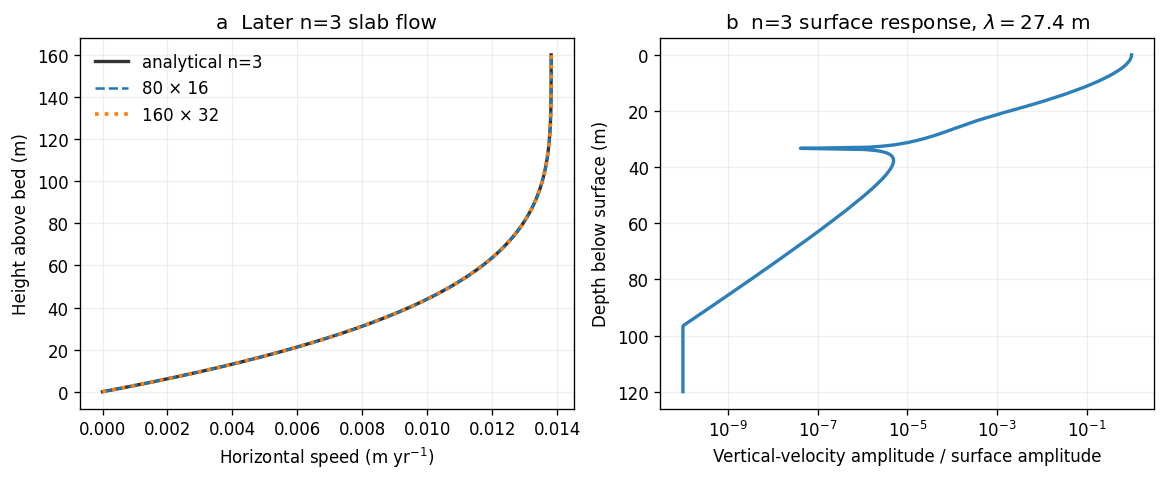

The slab softness is **2.146e-18 Pa$^{-3}$ yr$^{-1}$**. The factor-two surface meshes differ by at most **2.97e-03** in nondimensional velocity. Coarse/fine relative-divergence measures are **1.13e-15/2.27e-15** for the surface cell and **1.50e-15/3.00e-15** for the slab.

In [3]:
profile_heights = fine_slab["heights"]
analytic_profile = analytical_velocity(profile_heights)
sample_depths = np.linspace(0.0, 120.0, 300)
Xsample, Ysample = np.meshgrid(unit_x, sample_depths / 27.42)
vertical_amplitude = np.max(np.abs(unit_velocity(Xsample, Ysample)[..., 1]), axis=1)

fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.9), constrained_layout=True)
axes[0].plot(analytic_profile, profile_heights, color="0.2", lw=2, label="analytical n=3")
axes[0].plot(coarse_slab["profile"], profile_heights, "--", label="80 × 16")
axes[0].plot(fine_slab["profile"], profile_heights, ":", lw=2.2, label="160 × 32")
axes[0].set(xlabel="Horizontal speed (m yr$^{-1}$)", ylabel="Height above bed (m)",
            title="a  Later n=3 slab flow")
axes[0].legend(frameon=False)
axes[1].semilogx(np.maximum(vertical_amplitude, 1e-10), sample_depths, color="#2c7fb8", lw=2)
axes[1].invert_yaxis()
axes[1].set(xlabel="Vertical-velocity amplitude / surface amplitude",
            ylabel="Depth below surface (m)", title="b  n=3 surface response, $\lambda=27.4$ m")
plt.show()

display(Markdown(
    f"The slab softness is **{SOFTNESS:.3e} Pa$^{{-3}}$ yr$^{{-1}}$**. "
    f"The factor-two surface meshes differ by at most **{surface_mesh_difference:.2e}** in "
    f"nondimensional velocity. Coarse/fine relative-divergence measures are "
    f"**{coarse_surface['divergence_ratio']:.2e}/{fine_surface['divergence_ratio']:.2e}** "
    f"for the surface cell and **{coarse_slab['divergence_ratio']:.2e}/"
    f"{fine_slab['divergence_ratio']:.2e}** for the slab."
))

## Unified material-coordinate map

For each explicit surface case, trajectories are integrated backward through the n=3 surface velocity. This tabulates the initial depth $y_0=F(\theta,y)$ of material that ends the surface episode at pattern phase $\theta$ and depth $y$. The map is a material coordinate, not a fitted wrinkle. Values $y_0\le0$ identify material supplied through the accumulation boundary and receive the young limiting age; this also permits a surface unconformity rather than requiring every layer to be a smooth survivor.

The surface-made packet is reflected into the basal coordinate using $y=z_t-z$, where $z$ is height above the bed and $z_t$ locates the packet top. Ice above the packet has the young limiting age $a_y$. Horizontal shortening $C\le1$ maps the surface wavelength $\lambda$ to $C\lambda$. Backtracking through later slab shear for time $T_s$ gives

$$S(z)=F\!\left[\phi-\frac{2\pi T_s u(z)}{C\lambda},\ z_t-z\right].$$

A monotonic age law $a(S)=a_y+(4-a_y)\{1-\exp[-(S/\ell_a)^p]\}$ converts the initial surface depth to age. Thus every age reversal must come from the combined surface material map and later depth-dependent shear. The flat-surface control sets $F(\theta,y)=y$; the no-shear control sets $T_s=0$.

In [4]:
surface_cases = [
    {"name": "present target", "b": 0.05, "wavelength": 27.42, "speed_ratio": 0.0, "duration": 500.0},
    {"name": "slower target", "b": 0.03, "wavelength": 27.42, "speed_ratio": 0.0, "duration": 500.0},
    {"name": "long target", "b": 0.03, "wavelength": 27.42, "speed_ratio": 0.0, "duration": 1000.0},
    {"name": "co-moving target", "b": 0.05, "wavelength": 27.42, "speed_ratio": 1.0, "duration": 500.0},
    {"name": "windy target", "b": 0.10, "wavelength": 27.42, "speed_ratio": 0.0, "duration": 200.0},
    {"name": "very windy target", "b": 0.20, "wavelength": 27.42, "speed_ratio": 0.0, "duration": 200.0},
    {"name": "broad co-moving", "b": 0.03, "wavelength": 60.0, "speed_ratio": 1.0, "duration": 1000.0},
    {"name": "broad fixed", "b": 0.05, "wavelength": 60.0, "speed_ratio": 0.0, "duration": 500.0},
    {"name": "windy broad", "b": 0.10, "wavelength": 60.0, "speed_ratio": 0.0, "duration": 200.0},
    {"name": "very windy broad", "b": 0.20, "wavelength": 60.0, "speed_ratio": 0.0, "duration": 200.0},
    {"name": "extreme broad", "b": 0.30, "wavelength": 60.0, "speed_ratio": 0.0, "duration": 200.0},
]

map_phase = np.linspace(0.0, 1.0, 257, endpoint=False)
map_depth = np.linspace(0.0, 85.0, 341)

def backtrack_surface_map(case):
    X, Y = np.meshgrid(map_phase, map_depth)
    xhat = X.copy()
    yhat = Y / case["wavelength"]
    tau = case["b"] * case["duration"] / case["wavelength"]
    drift = SURFACE_SPEED * (1 - case["speed_ratio"]) / case["b"]
    steps = max(20, int(np.ceil(tau / 0.025)))
    step = -tau / steps

    def rhs(x, y):
        response = unit_velocity(x, y)
        return drift + response[..., 0], response[..., 1]

    for _ in range(steps):
        k1x, k1y = rhs(xhat, yhat)
        k2x, k2y = rhs(xhat + 0.5 * step * k1x, yhat + 0.5 * step * k1y)
        k3x, k3y = rhs(xhat + 0.5 * step * k2x, yhat + 0.5 * step * k2y)
        k4x, k4y = rhs(xhat + step * k3x, yhat + step * k3y)
        xhat += step * (k1x + 2 * k2x + 2 * k3x + k4x) / 6
        yhat += step * (k1y + 2 * k2y + 2 * k3y + k4y) / 6
    return yhat * case["wavelength"]

surface_maps = [backtrack_surface_map(case) for case in surface_cases]

def sample_surface_map(material_map, phase, end_depth):
    phase, end_depth = np.broadcast_arrays(np.asarray(phase), np.asarray(end_depth))
    phase_fraction = np.mod(phase / (2 * np.pi), 1.0)
    i_float = phase_fraction * len(map_phase)
    i0 = np.floor(i_float).astype(int) % len(map_phase)
    i1 = (i0 + 1) % len(map_phase)
    fx = i_float - np.floor(i_float)
    y_clipped = np.clip(end_depth, map_depth[0], map_depth[-1])
    j_float = (y_clipped - map_depth[0]) / (map_depth[1] - map_depth[0])
    j0 = np.minimum(np.floor(j_float).astype(int), len(map_depth) - 2)
    j1 = j0 + 1
    fy = np.minimum(j_float - j0, 1.0)
    values = (
        (1 - fx) * (1 - fy) * material_map[j0, i0]
        + fx * (1 - fy) * material_map[j0, i1]
        + (1 - fx) * fy * material_map[j1, i0]
        + fx * fy * material_map[j1, i1]
    )
    outside = (end_depth < map_depth[0]) | (end_depth > map_depth[-1])
    return np.where(outside, np.nan, values)

def sampled_slab_velocity(heights, profile=fine_slab["profile"]):
    return np.interp(np.asarray(heights), fine_slab["heights"], profile)

def model_age(parameters, depths, case, material_map, profile=fine_slab["profile"], flat=False):
    compression, shear_kyr, packet_top, phase, young_age, age_scale, age_power = parameters
    heights = H - np.asarray(depths)
    end_depth = packet_top - heights
    shear_displacement = shear_kyr * 1000 * np.interp(heights, fine_slab["heights"], profile)
    surface_phase = phase - 2 * np.pi * shear_displacement / (compression * case["wavelength"])
    map_depths = np.maximum(end_depth, 0.0)
    initial_depth = map_depths if flat else sample_surface_map(material_map, surface_phase, map_depths)
    initial_depth = np.where(end_depth <= 0.0, 0.0, initial_depth)
    clipped_depth = np.maximum(initial_depth, 0.0)
    modeled_age = young_age + (4.0 - young_age) * (
        1 - np.exp(-(clipped_depth / age_scale)**age_power)
    )
    return modeled_age, initial_depth

MODEL_ERROR = 0.15
fold_depth_grid = np.linspace(139.5, 155.5, 801)
depth_separation = depth[:, None] - depth[None, :]
sampling_density = np.exp(-0.5 * (depth_separation / 0.45)**2).sum(axis=1)
density_weights = 1.0 / sampling_density
density_weights /= density_weights.mean()

def objective(parameters, case, material_map):
    prediction, initial_depth = model_age(parameters, depth, case, material_map)
    if not np.all(np.isfinite(prediction)):
        return 1e4
    sigma = np.sqrt(relative_error**2 + MODEL_ERROR**2)
    data_term = np.average(((prediction - age) / sigma)**2, weights=density_weights)

    fold_prediction, fold_initial_depth = model_age(parameters, fold_depth_grid, case, material_map)
    peaks = find_peaks(fold_prediction, prominence=0.25, distance=90)[0]
    peaks = peaks[(fold_depth_grid[peaks] >= 141.0) & (fold_depth_grid[peaks] <= 155.3)]
    if len(peaks) != 3:
        return data_term + 1000.0 + 500.0 * abs(len(peaks) - 3)
    feature_term = np.mean(((fold_depth_grid[peaks] - observed_peak_depths) / 0.55)**2)
    feature_term += np.mean(((fold_prediction[peaks] - observed_peak_ages) / 0.30)**2)
    return data_term + feature_term

parameter_bounds = [
    (0.15, 1.0),            # horizontal compression C
    (10.0, 60.0),           # later shear duration (kyr)
    (18.0, 45.0),           # packet top above bed (m)
    (0.0, 2 * np.pi),       # core phase
    (0.30, 0.90),           # young age (Ma)
    (3.0, 80.0),            # age scale (m)
    (0.30, 3.0),            # age exponent
]

case_fits = []
for case_index, (case, material_map) in enumerate(zip(surface_cases, surface_maps)):
    result = differential_evolution(
        objective, parameter_bounds, args=(case, material_map), seed=30 + case_index,
        popsize=10, maxiter=160, tol=1e-6, polish=True, updating="immediate", workers=1,
    )
    case_fits.append(result)

best_case_index = int(np.argmin([result.fun for result in case_fits]))
best_case = surface_cases[best_case_index]
best_map = surface_maps[best_case_index]
best = case_fits[best_case_index].x

In [5]:
prediction, fitted_initial_depth = model_age(best, depth, best_case, best_map)
fine_curve_depth = np.linspace(119.0, 160.0, 2500)
fine_curve, _ = model_age(best, fine_curve_depth, best_case, best_map)
fold_curve, _ = model_age(best, fold_depth_grid, best_case, best_map)
model_peak_indices = find_peaks(fold_curve, prominence=0.25, distance=90)[0]
model_peak_indices = model_peak_indices[
    (fold_depth_grid[model_peak_indices] >= 141.0) & (fold_depth_grid[model_peak_indices] <= 155.3)
]
model_peak_depths = fold_depth_grid[model_peak_indices]
model_peak_ages = fold_curve[model_peak_indices]
rmse = np.sqrt(np.mean((prediction - age)**2))
weighted_rmse = np.sqrt(np.average((prediction - age)**2, weights=density_weights))
coarse_curve, _ = model_age(best, fine_curve_depth, best_case, best_map,
                            profile=coarse_slab["profile"])
mesh_age_difference = np.max(np.abs(fine_curve - coarse_curve))
flat_curve, _ = model_age(best, fine_curve_depth, best_case, best_map, flat=True)
no_shear = best.copy()
no_shear[1] = 0.0
surface_only_curve, _ = model_age(no_shear, fine_curve_depth, best_case, best_map)

case_table = [
    "| Surface case | $b$ (m yr$^{-1}$) | $\lambda$ (m) | $c/U$ | $T_b$ (yr) | Objective |",
    "|---|---:|---:|---:|---:|---:|",
]
for case, result in zip(surface_cases, case_fits):
    case_table.append(
        f"| {case['name']} | {case['b']:.2f} | {case['wavelength']:.2f} | "
        f"{case['speed_ratio']:.1f} | {case['duration']:.0f} | {result.fun:.3f} |"
    )
display(Markdown("\n".join(case_table)))

names = ["compression $C$", "shear duration (kyr)", "packet top $z_t$ (m)",
         "phase $\phi$ (rad)", "young age (Ma)", "age scale (m)", "age exponent"]
parameter_table = ["| Fitted parameter | Value |", "|---|---:|"]
parameter_table += [f"| {name} | {value:.4g} |" for name, value in zip(names, best)]
display(Markdown("\n".join(parameter_table)))

peak_comparison = ", ".join(
    f"{observed:.2f}/{modeled:.2f} m" for observed, modeled in zip(observed_peak_depths, model_peak_depths)
)
display(Markdown(
    f"The selected **{best_case['name']}** surface history uses $b={best_case['b']:.2f}$ m yr$^{{-1}}$, "
    f"$\lambda={best_case['wavelength']:.2f}$ m, $c/U={best_case['speed_ratio']:.1f}$, and "
    f"$T_b={best_case['duration']:.0f}$ yr. The unified fit has **{len(model_peak_depths)} folds**, "
    f"**{rmse:.3f} Ma** pointwise and **{weighted_rmse:.3f} Ma** depth-weighted RMS misfit. "
    f"Observed/modeled peak depths are {peak_comparison}. Doubling both slab mesh dimensions "
    f"changes the plotted prediction by at most **{mesh_age_difference:.2e} Ma**."
))

| Surface case | $b$ (m yr$^{-1}$) | $\lambda$ (m) | $c/U$ | $T_b$ (yr) | Objective |
|---|---:|---:|---:|---:|---:|
| present target | 0.05 | 27.42 | 0.0 | 500 | 7.817 |
| slower target | 0.03 | 27.42 | 0.0 | 500 | 10.625 |
| long target | 0.03 | 27.42 | 0.0 | 1000 | 7.877 |
| co-moving target | 0.05 | 27.42 | 1.0 | 500 | 7.781 |
| windy target | 0.10 | 27.42 | 0.0 | 200 | 7.759 |
| very windy target | 0.20 | 27.42 | 0.0 | 200 | 7.457 |
| broad co-moving | 0.03 | 60.00 | 1.0 | 1000 | 6.055 |
| broad fixed | 0.05 | 60.00 | 0.0 | 500 | 5.908 |
| windy broad | 0.10 | 60.00 | 0.0 | 200 | 5.576 |
| very windy broad | 0.20 | 60.00 | 0.0 | 200 | 6.120 |
| extreme broad | 0.30 | 60.00 | 0.0 | 200 | 6.277 |

| Fitted parameter | Value |
|---|---:|
| compression $C$ | 0.8678 |
| shear duration (kyr) | 47.68 |
| packet top $z_t$ (m) | 19.04 |
| phase $\phi$ (rad) | 6.024 |
| young age (Ma) | 0.7331 |
| age scale (m) | 31.65 |
| age exponent | 0.9506 |

The selected **windy broad** surface history uses $b=0.10$ m yr$^{-1}$, $\lambda=60.00$ m, $c/U=0.0$, and $T_b=200$ yr. The unified fit has **3 folds**, **0.412 Ma** pointwise and **0.346 Ma** depth-weighted RMS misfit. Observed/modeled peak depths are 144.99/144.72 m, 148.58/148.80 m, 152.91/152.60 m. Doubling both slab mesh dimensions changes the plotted prediction by at most **8.25e-03 Ma**.

## Flow and Waddington diagnostics

The two steady velocity fields used by the fitted history are shown on physical $x$--$y$ coordinates for the selected surface case. Following Waddington, Bolzan, and Alley (2001), define the engineering shear rate $G=u_y+w_x$, pure-strain difference $D=u_x-w_y$, and shear parameter $S=G/D$. The plotted quantity $(2/\pi)\tan^{-1}S$ is a bounded rendering of the same parameter: zero is pure-strain dominated and $\pm1$ is the $|S|\rightarrow\infty$ shear limit. This avoids allowing numerical noise in the nearly zero slab denominator to set the color scale.

The surface row uses $y=0$ at the surface and negative $y$ within the ice. It includes the pattern-frame background speed and uses upward-positive $w$. The slab row uses height $y$ above the bed. Rates are in yr$^{-1}$. The exact parallel slab has $D=0$, so its Waddington parameter is formally infinite wherever $G\ne0$.

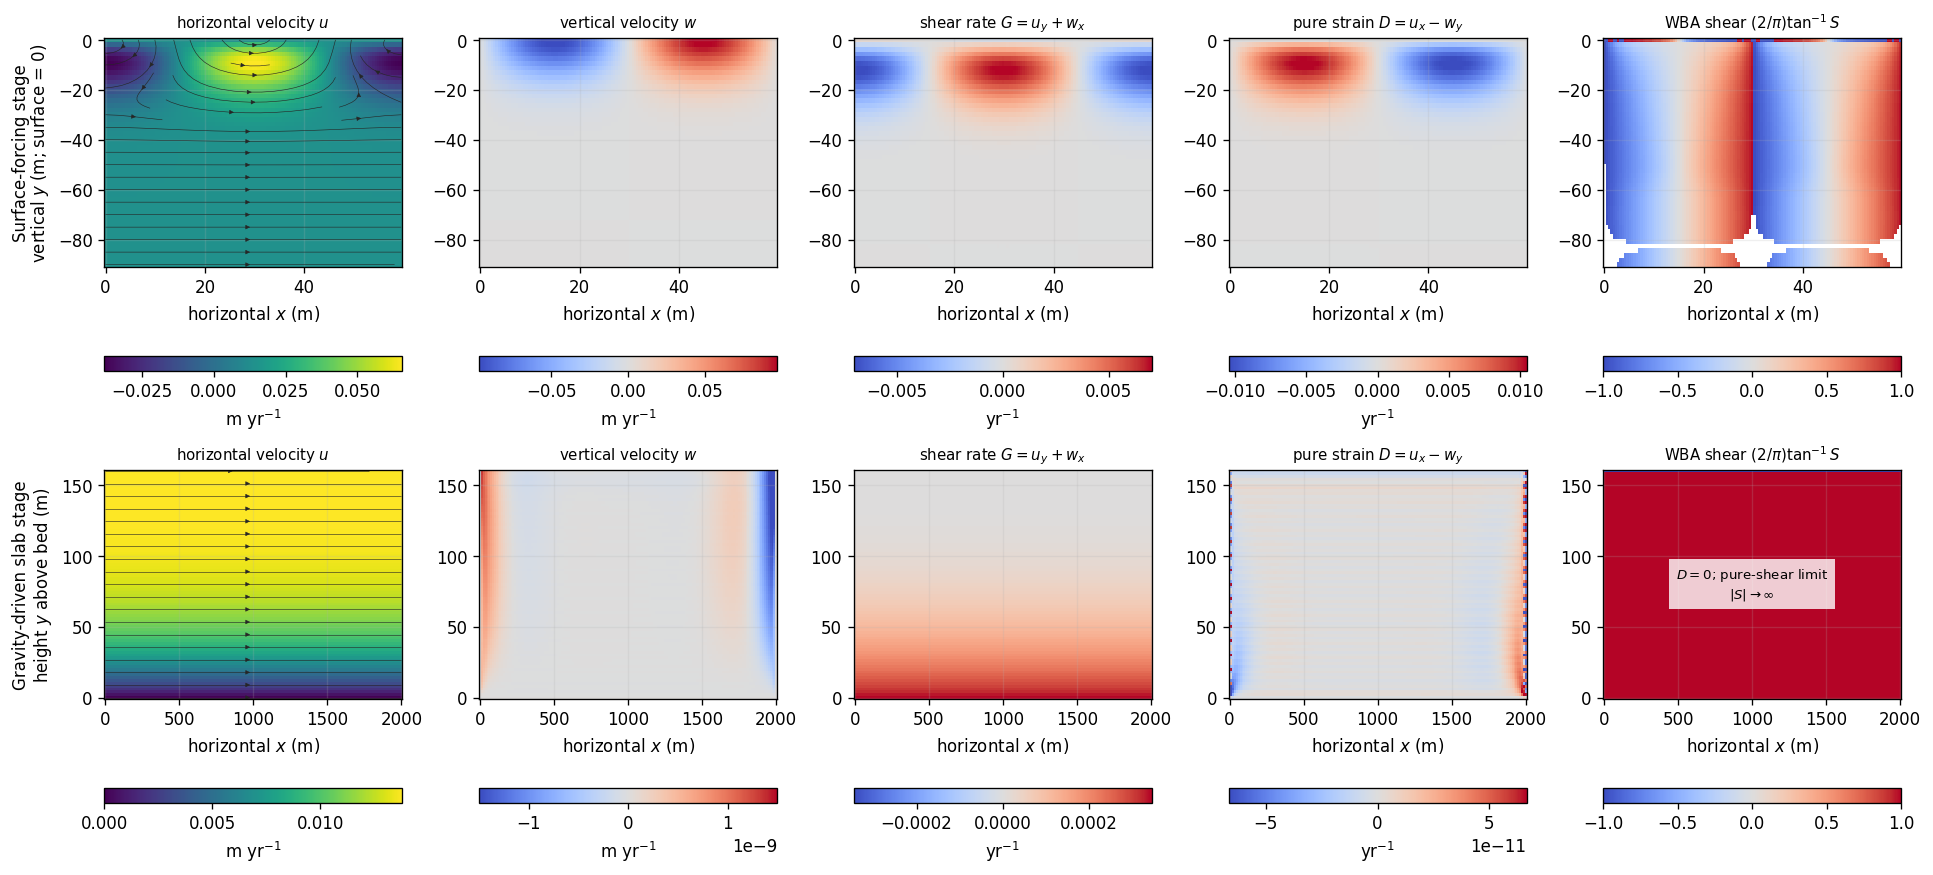

For the selected $n=3$ history, **48.7%** of the plotted surface cell and **100.0%** of the slab are shear-dominated ($|G|>|D|$). Maximum $|G|/|D|$ component scales are **7.19e-03/1.08e-02 yr$^{-1}$** for the surface stage and **3.45e-04/2.62e-10 yr$^{-1}$** for the slab. The slab's near-zero $D$ is the expected parallel-slab shear limit, not evidence that its strain rate is small.

In [6]:
def waddington_fields(x, y, horizontal, vertical):
    du_dy, du_dx = np.gradient(horizontal, y, x, edge_order=2)
    dw_dy, dw_dx = np.gradient(vertical, y, x, edge_order=2)
    shear_rate = du_dy + dw_dx
    pure_strain = du_dx - dw_dy
    tolerance = 1e-6 * max(np.max(np.abs(shear_rate)), np.max(np.abs(pure_strain)), 1e-30)
    bounded_shear_parameter = np.full_like(shear_rate, np.nan)
    resolved = np.abs(pure_strain) > tolerance
    bounded_shear_parameter[resolved] = (
        2 * np.arctan(shear_rate[resolved] / pure_strain[resolved]) / np.pi
    )
    return shear_rate, pure_strain, bounded_shear_parameter

def signed_limit(field):
    limit = float(np.quantile(np.abs(field), 0.995))
    return max(limit, 1e-16)

# Dimensional surface velocity for the selected forcing, in its pattern frame.
surface_wavelength = best_case["wavelength"]
surface_rate = best_case["b"]
surface_drift = SURFACE_SPEED * (1 - best_case["speed_ratio"])
surface_depth = unit_y * surface_wavelength
surface_rows = surface_depth <= min(1.5 * surface_wavelength, H)
surface_x = unit_x * surface_wavelength
surface_y = -surface_depth[surface_rows][::-1]
surface_u = (
    surface_drift + surface_rate * fine_unit_grid[surface_rows, :, 0]
)[::-1]
surface_w = (-surface_rate * fine_unit_grid[surface_rows, :, 1])[::-1]
surface_G, surface_D, surface_S_angle = waddington_fields(
    surface_x, surface_y, surface_u, surface_w
)

# Evaluate the full solved slab velocity on a structured physical grid.
slab_x = np.linspace(0.0, L, 161)
slab_y = np.linspace(0.0, H, 81)
slab_X, slab_Y = np.meshgrid(slab_x, slab_y)
slab_points = np.column_stack((slab_X.ravel(), slab_Y.ravel()))
slab_velocity = np.asarray(
    fine_slab["velocity"].at(slab_points, tolerance=1e-9)
).reshape(len(slab_y), len(slab_x), 2)
slab_u = slab_velocity[:, :, 0]
slab_w = slab_velocity[:, :, 1]
slab_G, slab_D, _ = waddington_fields(slab_x, slab_y, slab_u, slab_w)
slab_G_tolerance = 1e-6 * max(np.max(np.abs(slab_G)), 1e-30)
slab_S_angle = np.where(
    np.abs(slab_G) > slab_G_tolerance, np.sign(slab_G), 0.0
)

rows = [
    (surface_x, surface_y, surface_u, surface_w, surface_G, surface_D, surface_S_angle,
     "Surface-forcing stage"),
    (slab_x, slab_y, slab_u, slab_w, slab_G, slab_D, slab_S_angle,
     "Gravity-driven slab stage"),
]

fig, axes = plt.subplots(2, 5, figsize=(16.0, 7.2), constrained_layout=True)
column_titles = [
    r"horizontal velocity $u$", r"vertical velocity $w$",
    r"shear rate $G=u_y+w_x$", r"pure strain $D=u_x-w_y$",
    r"WBA shear $(2/\pi)\tan^{-1}S$",
]
for row_index, (x_axis, y_axis, u_field, w_field, G_field, D_field, S_field, row_name) in enumerate(rows):
    fields = [u_field, w_field, G_field, D_field, S_field]
    for column_index, (axis, field, title) in enumerate(zip(axes[row_index], fields, column_titles)):
        if column_index == 0:
            image = axis.pcolormesh(x_axis, y_axis, field, shading="auto", cmap="viridis")
        elif column_index == 4:
            image = axis.pcolormesh(
                x_axis, y_axis, field, shading="auto", cmap="coolwarm", vmin=-1, vmax=1
            )
        else:
            limit = signed_limit(field)
            image = axis.pcolormesh(
                x_axis, y_axis, field, shading="auto", cmap="coolwarm", vmin=-limit, vmax=limit
            )
        if column_index == 0:
            axis.streamplot(
                x_axis, y_axis, u_field, w_field, density=0.65,
                linewidth=0.35, color="0.15", arrowsize=0.55,
            )
        axis.set_title(title, fontsize=9)
        if row_index == 1 and column_index == 4:
            axis.text(
                0.5, 0.5, r"$D=0$; pure-shear limit" + "\n" + r"$|S|\rightarrow\infty$",
                ha="center", va="center", transform=axis.transAxes,
                fontsize=8, bbox={"facecolor": "white", "alpha": 0.8, "edgecolor": "none"},
            )
        axis.set_xlabel("horizontal $x$ (m)")
        if column_index == 0:
            axis.set_ylabel(
                "vertical $y$ (m; surface = 0)" if row_index == 0
                else "height $y$ above bed (m)"
            )
            axis.text(
                -0.28, 0.5, row_name, rotation=90, va="center", ha="center",
                transform=axis.transAxes, fontsize=10,
            )
        units = "m yr$^{-1}$" if column_index < 2 else ("yr$^{-1}$" if column_index < 4 else "")
        fig.colorbar(image, ax=axis, orientation="horizontal", pad=0.13, fraction=0.07, label=units)
plt.show()

surface_shear_fraction = np.mean(np.abs(surface_G) > np.abs(surface_D))
slab_shear_fraction = np.mean(np.abs(slab_G) > np.abs(slab_D))
display(Markdown(
    f"For the selected $n={GLEN_N:g}$ history, **{100 * surface_shear_fraction:.1f}%** of the "
    f"plotted surface cell and **{100 * slab_shear_fraction:.1f}%** of the slab are "
    f"shear-dominated ($|G|>|D|$). Maximum $|G|/|D|$ component scales are "
    f"**{np.max(np.abs(surface_G)):.2e}/{np.max(np.abs(surface_D)):.2e} yr$^{{-1}}$** "
    f"for the surface stage and **{np.max(np.abs(slab_G)):.2e}/"
    f"{np.max(np.abs(slab_D)):.2e} yr$^{{-1}}$** for the slab. The slab's near-zero "
    f"$D$ is the expected parallel-slab shear limit, not evidence that its strain rate is small."
))

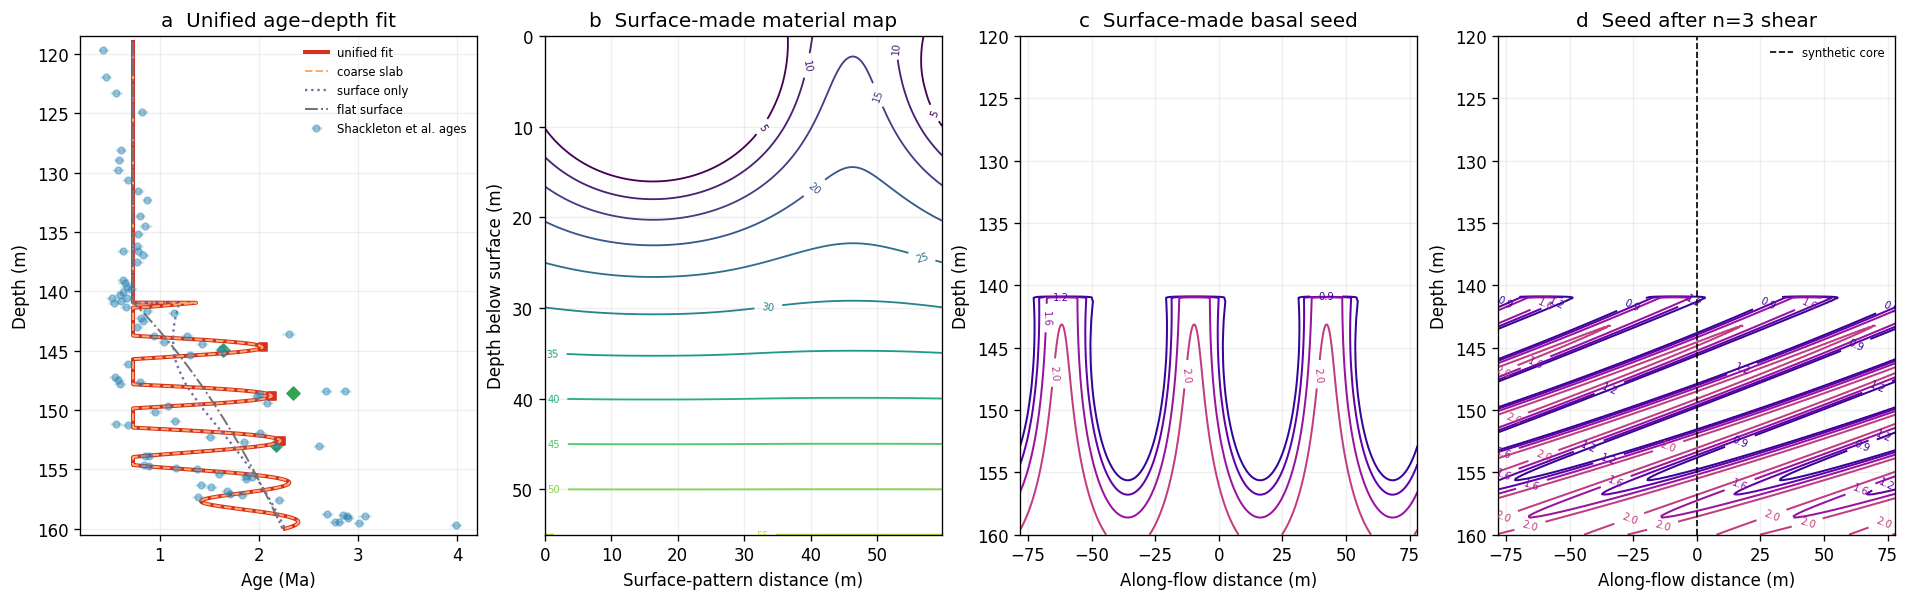

In [7]:
compression, shear_kyr, packet_top, phase, young_age, age_scale, age_power = best

fig, axes = plt.subplots(1, 4, figsize=(15.8, 4.9), constrained_layout=True)
axes[0].errorbar(age, depth, xerr=relative_error, fmt="o", ms=4, alpha=0.42,
                 color="#2c7fb8", ecolor="#7fcdbb", label="Shackleton et al. ages")
axes[0].plot(fine_curve, fine_curve_depth, color="#d7301f", lw=2.4, label="unified fit")
axes[0].plot(coarse_curve, fine_curve_depth, "--", color="#fdae6b", lw=1.2, label="coarse slab")
axes[0].plot(surface_only_curve, fine_curve_depth, ":", color="#756bb1", lw=1.4,
             label="surface only")
axes[0].plot(flat_curve, fine_curve_depth, "-.", color="0.45", lw=1.2, label="flat surface")
axes[0].scatter(observed_peak_ages, observed_peak_depths, marker="D", s=30, color="#31a354")
axes[0].scatter(model_peak_ages, model_peak_depths, marker="s", s=28, color="#d7301f")
axes[0].set(xlabel="Age (Ma)", ylabel="Depth (m)", title="a  Unified age–depth fit",
            ylim=(160.5, 118.5), xlim=(0.2, 4.2))
axes[0].legend(frameon=False, fontsize=7)

surface_x = map_phase * best_case["wavelength"]
surface_depth_limit = min(55.0, map_depth[-1])
surface_rows = map_depth <= surface_depth_limit
levels = np.arange(5.0, 61.0, 5.0)
contours = axes[1].contour(surface_x, map_depth[surface_rows], best_map[surface_rows],
                          levels=levels, cmap="viridis", linewidths=1.1)
axes[1].clabel(contours, fmt="%.0f", fontsize=6)
axes[1].invert_yaxis()
axes[1].set(xlabel="Surface-pattern distance (m)", ylabel="Depth below surface (m)",
            title="b  Surface-made material map")

x_basal = np.linspace(-1.5 * compression * best_case["wavelength"],
                      1.5 * compression * best_case["wavelength"], 501)
z_basal = np.linspace(0.0, 40.0, 321)
X, Z = np.meshgrid(x_basal, z_basal)
Y = packet_top - Z

def section_age(shear_time_kyr):
    displacement = shear_time_kyr * 1000 * sampled_slab_velocity(Z)
    theta = phase + 2 * np.pi * (X - displacement) / (compression * best_case["wavelength"])
    initial_depth = sample_surface_map(best_map, theta, np.maximum(Y, 0.0))
    initial_depth = np.where(Y <= 0.0, 0.0, initial_depth)
    return young_age + (4.0 - young_age) * (
        1 - np.exp(-(np.maximum(initial_depth, 0.0) / age_scale)**age_power)
    )

for axis, field, title in zip(
    axes[2:], [section_age(0.0), section_age(shear_kyr)],
    ["c  Surface-made basal seed", "d  Seed after n=3 shear"],
):
    contours = axis.contour(X, H - Z, field, levels=[0.7, 0.9, 1.2, 1.6, 2.0, 2.5, 3.0, 3.5],
                            cmap="plasma", linewidths=1.2)
    axis.clabel(contours, fmt="%.1f", fontsize=6)
    axis.set(xlabel="Along-flow distance (m)", ylabel="Depth (m)", title=title,
             ylim=(160.0, 120.0))
axes[3].axvline(0.0, color="black", ls="--", lw=1.0, label="synthetic core")
axes[3].legend(frameon=False, fontsize=7)
plt.show()

## Interpretation

The unified model passes the structural target. A fixed 60 m surface pattern with $b=0.10$ m yr$^{-1}$ for 200 yr, followed by modest horizontal shortening and 47.7 kyr of n=3 slab shear, produces all three independently defined folds. Their depths are within 0.31 m of the observed peaks, the pointwise RMS age misfit is 0.412 Ma, and the factor-two slab change is 0.008 Ma. This establishes compatibility, not uniqueness: surface duration, band speed, shortening, packet placement, and shear duration trade off.

The successful case is not a smooth-wrinkle solution. It uses the accumulation boundary, represented by $y_0\le0$, to insert young material and form a surface unconformity; later shear repeats and rotates that boundary through the core. The flat-surface and surface-only controls show that neither stage alone reproduces the three measured lobes. The combined discontinuity-plus-shear history is therefore the testable claim.

Important omissions remain. The transfer from a near-surface packet to the bed is represented by reflection, translation, and uniform horizontal shortening rather than a solved emergence-flow history. The free surface, firn compaction, diffusion, three-dimensional flow, and the detailed age of newly deposited material are absent. The 0.10 m yr$^{-1}$ forcing is an aggressive windy end member, and the fitted parameters should be read as targets for a future transport model, not as a Little Ice Age reconstruction.